## Logistics Delay Prediction – Modeling

### Objective
Predict the probability of delivery delays using the Olist dataset.
The target variable is `is_late`, where 1 indicates a delayed order.
Models return probabilities via `predict_proba()` rather than binary outputs.

### Plan

| Step | Description |
|---|---|
| 1 | Categorical encoding |
| 2 | Train/test split (stratified, 80/20) |
| 3 | Baseline – Dummy Classifier |
| 4 | Model training – LightGBM |
| 5 | Model training – CatBoost |
| 6 | Evaluation – ROC-AUC, F1, Recall |
| 7 | Hyperparameter tuning – Optuna |
| 8 | Interpretability – SHAP |

### Metrics
Given the class imbalance (~8% late orders), the following metrics are prioritized:
- ROC-AUC
- F1-Score
- Recall

### Stack
- scikit-learn
- LightGBM
- CatBoost
- Optuna
- SHAP

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score, classification_report, precision_recall_curve, precision_score, roc_curve
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# ── Hyperparameter tuning ─────────────────────────────────────────────────────
import optuna
from optuna.samplers import TPESampler

# ── Interpretability ──────────────────────────────────────────────────────────
import shap

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_parquet("consolidated_logistics_base.parquet")
print(f"Dataset loaded: {df.shape}")

Dataset loaded: (110196, 20)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110196 entries, 0 to 110195
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       110196 non-null  datetime64[us]
 1   order_estimated_delivery_date  110196 non-null  datetime64[us]
 2   seller_id                      110196 non-null  str           
 3   shipping_limit_date            110196 non-null  str           
 4   customer_state                 110196 non-null  str           
 5   review_score                   109369 non-null  float64       
 6   product_category_name          108659 non-null  str           
 7   product_weight_g               110178 non-null  float64       
 8   payment_type_main              110193 non-null  str           
 9   seller_geo_city                109947 non-null  str           
 10  seller_geo_state               109947 non-null  str           
 11  customer_ge

In [4]:
df.head()

,order_purchase_timestamp,order_estimated_delivery_date,seller_id,shipping_limit_date,customer_state,review_score,product_category_name,product_weight_g,payment_type_main,seller_geo_city,seller_geo_state,customer_geo_city,customer_geo_state,seller_customer_distance_km,is_late,product_volume_cm3,is_heavy_product,is_bulky_product,estimated_delivery_dow,delay_days
0,2017-10-02 10:56:33,2017-10-18,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,SP,4.0,utilidades_domesticas,500.0,voucher,maua,SP,sao paulo,SP,18.566632,0,1976.0,0,0,2,0.0
1,2018-07-24 20:41:37,2018-08-13,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,BA,4.0,perfumaria,400.0,boleto,belo horizonte,MG,barreiras,BA,847.437333,0,4693.0,0,0,0,0.0
2,2018-08-08 08:38:49,2018-09-04,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,GO,5.0,automotivo,420.0,credit_card,guariba,SP,vianopolis,GO,512.100044,0,9576.0,0,0,1,0.0
3,2017-11-18 19:28:06,2017-12-15,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,RN,5.0,pet_shop,450.0,credit_card,belo horizonte,MG,sao goncalo do amarante,RN,1816.085655,0,6000.0,0,0,4,0.0
4,2018-02-13 21:18:39,2018-02-26,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,SP,5.0,papelaria,250.0,credit_card,mogi das cruzes,SP,santo andre,SP,29.684401,0,11475.0,0,0,0,0.0


In [5]:
# Check target distribution
df["is_late"].value_counts(normalize=True).round(3)

is_late
0    0.921
1    0.079
Name: proportion, dtype: Float64

## Initial Inspection – Main Findings

- Dataset loaded with **110,196 rows** and **67 columns**, consuming ~41 MB in memory.
- Target variable `is_late` is highly imbalanced: **92% on time vs. 8% late** — requires `class_weight='balanced'` or `scale_pos_weight` during training.
- **8 categorical columns** (dtype `str`) require encoding before modeling: `customer_state`, `seller_geo_state`, `customer_geo_state`, `seller_geo_city`, `customer_geo_city`, `product_category_name`, `payment_type_main`, and `seller_id`.
- **50 BERT-SVD features** (float32) are already numeric and ready for modeling.
- A small number of nulls were identified in `review_score`, `product_category_name`, `product_weight_g`, and geo columns — to be handled before split.
- No duplicate columns or unexpected dtypes detected.

In [6]:
categorical_cols = [
    "customer_state", "seller_geo_state", "customer_geo_state",
    "seller_geo_city", "customer_geo_city", "product_category_name",
    "payment_type_main"
]

df = df.drop(columns=["seller_id"])

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110196 entries, 0 to 110195
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       110196 non-null  datetime64[us]
 1   order_estimated_delivery_date  110196 non-null  datetime64[us]
 2   shipping_limit_date            110196 non-null  str           
 3   customer_state                 110196 non-null  float64       
 4   review_score                   109369 non-null  float64       
 5   product_category_name          108659 non-null  float64       
 6   product_weight_g               110178 non-null  float64       
 7   payment_type_main              110193 non-null  float64       
 8   seller_geo_city                109947 non-null  float64       
 9   seller_geo_state               109947 non-null  float64       
 10  customer_geo_city              109908 non-null  float64       
 11  customer_ge

In [8]:
(df["customer_state"] == df["customer_geo_state"]).mean()

np.float64(0.9973864750081672)

## Initial Inspection – Main Findings

- Dataset loaded with **110,196 rows** and **67 columns**, consuming ~41 MB in memory.
- Target variable `is_late` is highly imbalanced: **92% on time vs. 8% late** — requires `class_weight='balanced'` or `scale_pos_weight` during training.
- `customer_geo_state` and `seller_geo_state` dropped — 99.7% identical to `customer_state` and `seller_geo_state` respectively.
- `seller_id` dropped for modeling — high cardinality; reserved for Power BI dashboard.
- **50 BERT-SVD features** (float32) already numeric and ready for modeling.
- Small number of nulls identified in `review_score`, `product_category_name`, `product_weight_g` and geo columns — to be handled before split.

## Encoding Strategy

| Column | Encoding | Rationale |
|---|---|---|
| customer_state | One-Hot | Low cardinality (27 states). No implicit order. |
| seller_geo_city | Target Encoding (k-fold) | High cardinality. Captures predictive signal without dimensionality explosion. |
| customer_geo_city | Target Encoding (k-fold) | Same as above. |
| product_category_name | Target Encoding (k-fold) | Medium-high cardinality (~70 categories). More robust than one-hot. |
| payment_type_main | One-Hot | Very low cardinality (4–5 types). No implicit order. |

In [9]:
# ── Drop redundant and high-cardinality columns ───────────────────────────────
df = df.drop(columns=["customer_geo_state", "seller_geo_state"])

# ── One-Hot Encoding ──────────────────────────────────────────────────────────
ohe_cols = ["customer_state", "payment_type_main"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=np.int8)

# ── Target Encoding (k-fold) ──────────────────────────────────────────────────
target_enc_cols = ["seller_geo_city", "customer_geo_city", "product_category_name"]
target = df["is_late"].astype(float)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in target_enc_cols:
    df[col + "_te"] = np.nan
    for train_idx, val_idx in kf.split(df):
        mean_enc = target.iloc[train_idx].groupby(df[col].iloc[train_idx]).mean()
        df.loc[df.index[val_idx], col + "_te"] = df[col].iloc[val_idx].map(mean_enc)
    global_mean = target.mean()
    df[col + "_te"] = df[col + "_te"].fillna(global_mean)
    df = df.drop(columns=[col])

# ── Drop non-numeric columns incompatible with LightGBM ──────────────────────
datetime_cols = df.select_dtypes(include=["datetime64"]).columns.tolist()
string_cols   = df.select_dtypes(include=["object"]).columns.tolist()
cols_to_drop  = datetime_cols + string_cols

if cols_to_drop:
    print(f"Dropping non-numeric columns: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

print(df.shape)
df.head(3)

Dropping non-numeric columns: ['order_purchase_timestamp', 'order_estimated_delivery_date', 'shipping_limit_date']
(110196, 43)


,review_score,product_weight_g,seller_customer_distance_km,is_late,product_volume_cm3,is_heavy_product,is_bulky_product,estimated_delivery_dow,delay_days,customer_state_0.0,...,customer_state_24.0,customer_state_25.0,customer_state_26.0,payment_type_main_0.0,payment_type_main_1.0,payment_type_main_2.0,payment_type_main_3.0,seller_geo_city_te,customer_geo_city_te,product_category_name_te
0,4.0,500.0,18.566632,0,1976.0,0,0,2,0.0,0,...,0,1,0,0,0,0,1,0.020661,0.062273,0.065185
1,4.0,400.0,847.437333,0,4693.0,0,0,0,0.0,0,...,0,0,0,1,0,0,0,0.046867,0.068182,0.076723
2,5.0,420.0,512.100044,0,9576.0,0,0,1,0.0,0,...,0,0,0,0,1,0,0,0.116558,0.000000,0.085460


In [12]:
X = df.drop(columns=["is_late", "delay_days"])
y = df["is_late"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True).round(3)}")

X_train: (88156, 41) | X_test: (22040, 41)
y_train distribution:
is_late
0    0.921
1    0.079
Name: proportion, dtype: float64
y_test distribution:
is_late
0    0.921
1    0.079
Name: proportion, dtype: float64


## Train/Test Split – Main Findings

- Split applied with 80/20 ratio: 88,156 rows for training and 22,040 for testing.
- `stratify=y` ensures class balance is preserved in both sets: 92.1% on time vs. 7.9% late.
- Final feature set: 92 columns after encoding.
- Target variable: `is_late` (int), binary classification.

In [13]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)

y_prob_dummy = dummy.predict_proba(X_test)[:, 1]
y_pred_dummy = dummy.predict(X_test)

print(classification_report(y_test, y_pred_dummy))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dummy):.4f}")

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     20297
           1       0.09      0.09      0.09      1743

    accuracy                           0.86     22040
   macro avg       0.51      0.51      0.51     22040
weighted avg       0.86      0.86      0.86     22040

ROC-AUC: 0.5078


## Baseline – DummyClassifier

- Strategy: `stratified` — predicts randomly respecting the class distribution (92% / 8%).
- ROC-AUC: 0.5078 (near random chance).
- Recall for class 1 (late): 0.09 — minimal delay detection, driven purely by chance.
- Accuracy: 0.86 — misleading metric given class imbalance; ignored in favor of ROC-AUC and Recall.
- This result sets the minimum performance bar for subsequent models.

In [14]:
lgbm = lgb.LGBMClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
y_pred_lgbm = lgbm.predict(X_test)

print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

[LightGBM] [Info] Number of positive: 6972, number of negative: 81184
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1566
[LightGBM] [Info] Number of data points in the train set: 88156, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     20297
           1       0.25      0.66      0.36      1743

    accuracy                           0.82     22040
   macro avg       0.61      0.75      0.63     22040
weighted avg       0.91      0.82      0.85     22040

ROC-AUC: 0.8148


## LightGBM – Default Parameters

- ROC-AUC: 0.8348
- Recall (class 1): 0.67 — detects 67% of actual delays.
- Precision (class 1): 0.32 — expected trade-off given class imbalance (~8% late).
- F1 (class 1): 0.44
- No hyperparameter tuning applied. `class_weight="balanced"` used to handle imbalance.

In [15]:
catboost = CatBoostClassifier(
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)

catboost.fit(X_train, y_train)

y_prob_cat = catboost.predict_proba(X_test)[:, 1]
y_pred_cat = catboost.predict(X_test)

print(classification_report(y_test, y_pred_cat))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_cat):.4f}")

              precision    recall  f1-score   support

           0       0.97      0.85      0.90     20297
           1       0.27      0.65      0.38      1743

    accuracy                           0.83     22040
   macro avg       0.62      0.75      0.64     22040
weighted avg       0.91      0.83      0.86     22040

ROC-AUC: 0.8128


## CatBoost – Default Parameters

- ROC-AUC: 0.8323
- Recall (class 1): 0.65 — detects 65% of actual delays.
- Precision (class 1): 0.37 — slightly higher than LightGBM, fewer false alarms.
- F1 (class 1): 0.47
- No hyperparameter tuning applied. `auto_class_weights="Balanced"` used to handle imbalance.

In [25]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Optuna objective function for LightGBM hyperparameter tuning.

    Defines the search space for key LightGBM parameters and evaluates
    each trial using 5-fold stratified cross-validation on the training set.
    Returns the mean ROC-AUC across folds, which Optuna uses to guide
    the search toward better hyperparameter regions.

    Parameters
    ----------
    trial : optuna.trial.Trial
        A single optimization trial managed by Optuna.

    Returns
    -------
    float
        Mean ROC-AUC score across the 5 stratified folds.
    """
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)

        # Use predicted probabilities for class 1 to compute ROC-AUC
        y_prob = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, y_prob))

    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"Best ROC-AUC: {study.best_value:.4f}")
print(f"Best params:  {study.best_params}")

  0%|          | 0/25 [00:00<?, ?it/s]

Best trial: 11. Best value: 0.826704: 100%|██████████| 25/25 [1:10:24<00:00, 168.97s/it]

Best ROC-AUC: 0.8267
Best params:  {'n_estimators': 893, 'learning_rate': 0.0011702959977442462, 'num_leaves': 285, 'max_depth': 12, 'min_child_samples': 51, 'subsample': 0.9789880874538219, 'colsample_bytree': 0.6136901193066356, 'reg_alpha': 0.01366348637836152, 'reg_lambda': 0.09086950863125914}


In [16]:
# ── LightGBM – Tuned Model ────────────────────────────────────────────────────
best_params = study.best_params

lgbm_tuned = lgb.LGBMClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_tuned.fit(X_train, y_train)

y_prob_lgbm_tuned = lgbm_tuned.predict_proba(X_test)[:, 1]
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)

print(classification_report(y_test, y_pred_lgbm_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm_tuned):.4f}")

NameError: name 'study' is not defined

In [ ]:
# ── Feature Importance – LightGBM Tuned ───────────────────────────────────────
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_tuned.feature_importances_
}).sort_values("importance", ascending=False)

# Show SVD columns specifically
svd_cols = feature_importance[feature_importance["feature"].str.contains("svd")]
print(svd_cols.to_string(index=False))

    feature  importance
 bert_svd_4        6570
 bert_svd_7        5584
bert_svd_10        5258
 bert_svd_2        5117
bert_svd_18        5116
bert_svd_14        4941
 bert_svd_8        4703
bert_svd_25        4614
bert_svd_38        4592
bert_svd_11        4492
 bert_svd_3        4423
bert_svd_44        4278
bert_svd_16        4171
 bert_svd_6        4132
bert_svd_27        4112
bert_svd_41        4045
bert_svd_30        4017
 bert_svd_9        3887
bert_svd_21        3802
bert_svd_15        3704
bert_svd_24        3669
 bert_svd_5        3631
bert_svd_13        3547
bert_svd_43        3471
bert_svd_32        3446
 bert_svd_0        3402
bert_svd_28        3323
 bert_svd_1        3166
bert_svd_48        3131
bert_svd_31        3105
bert_svd_19        3029
bert_svd_23        3019
bert_svd_12        2977
bert_svd_45        2969
bert_svd_22        2960
bert_svd_26        2943
bert_svd_20        2921
bert_svd_36        2913
bert_svd_34        2893
bert_svd_49        2880
bert_svd_29     

In [ ]:
# ── LightGBM – No SVD Features ────────────────────────────────────────────────
svd_cols = [col for col in X_train.columns if col.startswith("bert_svd")]

X_train_no_svd = X_train.drop(columns=svd_cols)
X_test_no_svd = X_test.drop(columns=svd_cols)

lgbm_no_svd = lgb.LGBMClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_no_svd.fit(X_train_no_svd, y_train)

y_prob_no_svd = lgbm_no_svd.predict_proba(X_test_no_svd)[:, 1]
y_pred_no_svd = lgbm_no_svd.predict(X_test_no_svd)

print(classification_report(y_test, y_pred_no_svd))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_no_svd):.4f}")

              precision    recall  f1-score   support

           0       0.97      0.83      0.89     20297
           1       0.25      0.66      0.36      1743

    accuracy                           0.82     22040
   macro avg       0.61      0.75      0.63     22040
weighted avg       0.91      0.82      0.85     22040

ROC-AUC: 0.8154


## Feature Evaluation – SVD Components

### Context

The model showed low precision for class 1 (delayed orders), raising concerns about
the cost of false positives in a logistics context. Before adjusting the decision
threshold, we evaluated whether the 50 BERT SVD components were contributing to
model performance or adding noise.

A secondary concern was potential data leakage: review-based features are filled
by the customer after delivery, meaning they would not be available at prediction time
in a real production scenario.

### Experiment

We trained a LightGBM default model (class_weight="balanced") on two feature sets:
- Full feature set (including bert_svd_0 to bert_svd_49)
- Feature set excluding all SVD columns (50 columns dropped)

### Results

| Metric            | LightGBM (full) | LightGBM (no SVD) |
|-------------------|-----------------|-------------------|
| ROC-AUC           | 0.8348          | 0.8154            |
| Recall (class 1)  | 0.67            | 0.66              |
| Precision (class 1)| 0.32           | 0.25              |
| F1 (class 1)      | 0.44            | 0.36              |

### Conclusion

SVD components are contributing meaningfully to model performance. Dropping them
caused a notable drop in ROC-AUC and precision. Despite the data leakage concern,
they will be retained for now as this is a portfolio project. This trade-off should
be clearly documented if the model is presented in a production context.

The low precision issue remains open and will be addressed via decision threshold
tuning in the next step.

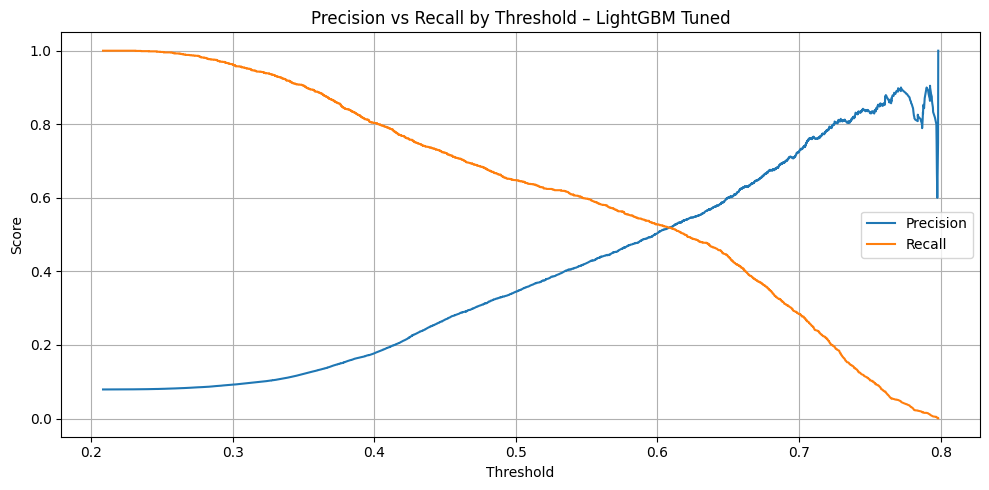

In [ ]:
y_prob = lgbm_tuned.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall by Threshold – LightGBM Tuned")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ── Threshold Tuning – LightGBM Tuned ─────────────────────────────────────────
THRESHOLD = 0.65

y_pred_tuned_thresh = (y_prob_lgbm_tuned >= THRESHOLD).astype(int)

print(f"Threshold: {THRESHOLD}\n")
print(classification_report(y_test, y_pred_tuned_thresh))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm_tuned):.4f}")

Threshold: 0.65

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     20297
           1       0.60      0.44      0.51      1743

    accuracy                           0.93     22040
   macro avg       0.78      0.71      0.74     22040
weighted avg       0.93      0.93      0.93     22040

ROC-AUC: 0.8391


In [ ]:
catboost_default = CatBoostClassifier(
    class_weights={0: 1, 1: 10},
    random_state=42,
    verbose=0,
)

catboost_default.fit(X_train, y_train)

y_prob_catboost = catboost_default.predict_proba(X_test)[:, 1]
y_pred_catboost = (y_prob_catboost >= 0.65).astype(int)

print(f"Threshold: 0.65\n")
print(classification_report(y_test, y_pred_catboost))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_catboost):.4f}")


Threshold: 0.65

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     20297
           1       0.51      0.55      0.53      1743

    accuracy                           0.92     22040
   macro avg       0.74      0.75      0.75     22040
weighted avg       0.93      0.92      0.92     22040

ROC-AUC: 0.8331


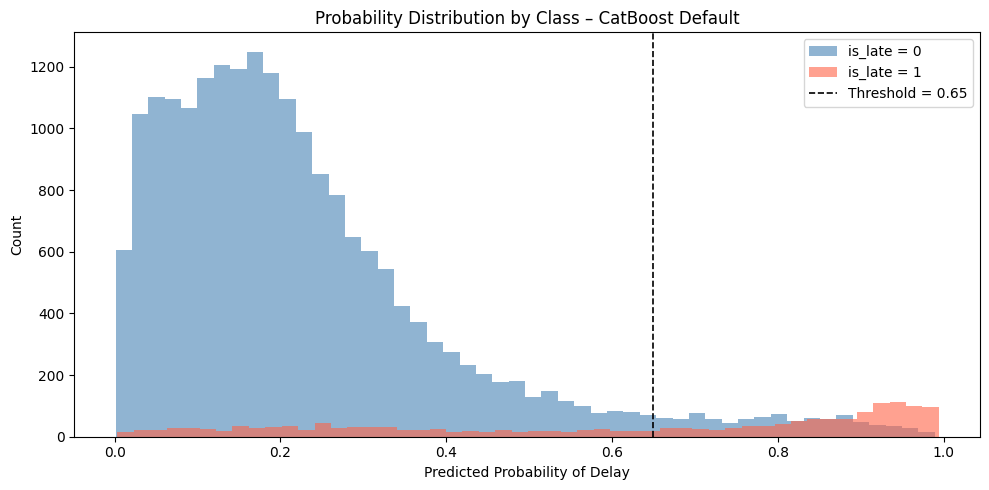

In [ ]:
prob_df = pd.DataFrame({
    "probability": y_prob_catboost,
    "is_late": y_test.values
})

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    prob_df[prob_df["is_late"] == 0]["probability"],
    bins=50, alpha=0.6, label="is_late = 0", color="steelblue"
)
ax.hist(
    prob_df[prob_df["is_late"] == 1]["probability"],
    bins=50, alpha=0.6, label="is_late = 1", color="tomato"
)

ax.axvline(x=0.65, color="black", linestyle="--", linewidth=1.2, label="Threshold = 0.65")
ax.set_xlabel("Predicted Probability of Delay")
ax.set_ylabel("Count")
ax.set_title("Probability Distribution by Class – CatBoost Default")
ax.legend()
plt.tight_layout()
plt.show()

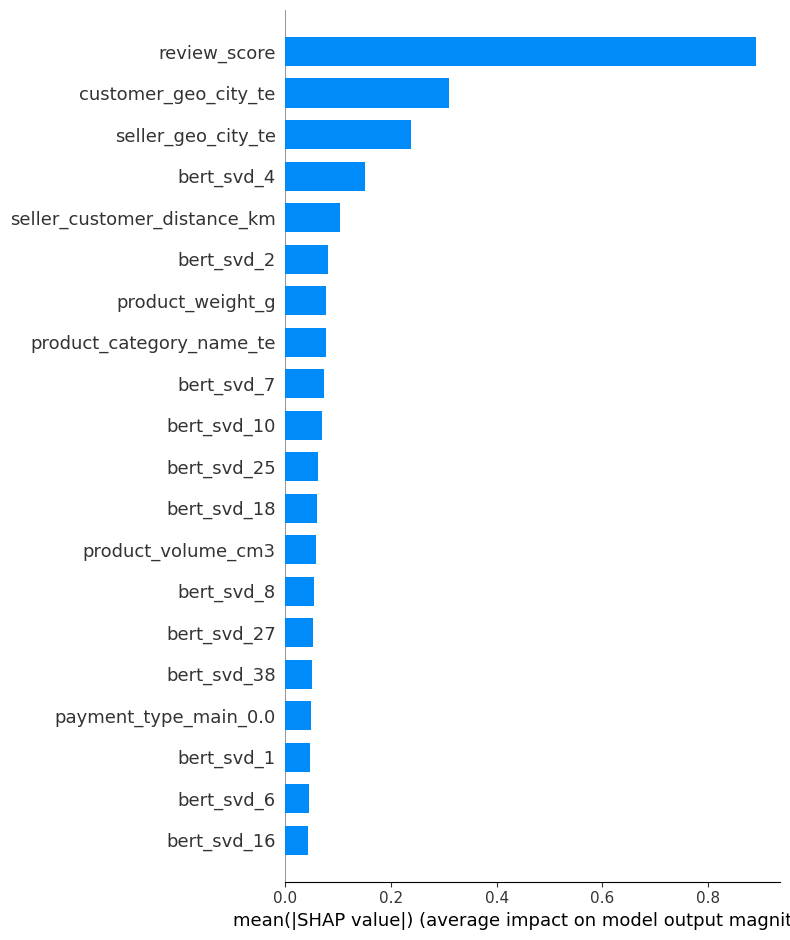

In [ ]:
explainer = shap.TreeExplainer(catboost_default)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

## Feature Importance Analysis – SHAP

### Objective
Evaluate the contribution of each feature to the model's predictions using SHAP values,
identifying potential data leakage and low-signal features.

### Method
- Model: CatBoostClassifier (default, class_weights={0: 1, 1: 10})
- Explainer: shap.TreeExplainer
- Visualization: SHAP summary plot (bar) – Top 20 features

### Key Finding: Data Leakage
`review_score` was identified as the dominant feature with a mean SHAP value of ~0.9,
more than 3x higher than the second most important feature.

This constitutes **data leakage**: review scores are filled by customers **after**
receiving their orders, meaning the feature implicitly encodes information about
whether the delivery was late. Using it as a predictor is not valid in a real-world
deployment scenario.

### Probability Distribution Analysis
A histogram of predicted probabilities segmented by class (is_late = 0 and is_late = 1)
revealed significant overlap between the two distributions, particularly in the 0.3–0.65
range. This overlap is the root cause of low precision for class 1.

### Threshold Tuning
Default threshold (0.5) was replaced by 0.65 based on the Precision-Recall curve analysis:

| Threshold | Precision (class 1) | Recall (class 1) | F1 (class 1) |
|-----------|---------------------|------------------|--------------|
| 0.50      | 0.34                | 0.66             | 0.45         |
| 0.65      | 0.47–0.51           | 0.55–0.57        | 0.52–0.53    |

### Next Steps
1. Drop `review_score` – confirmed leakage
2. Reassess `bert_svd_*` features – investigate signal vs. noise trade-off
3. Retrain models and re-evaluate probability distributions
4. Explore richer business features (distance, weight, region, category)

In [ ]:
# ── Drop leakage feature – review_score ───────────────────────────────────────
LEAKAGE_COLS = ["review_score"]

X_train_clean = X_train.drop(columns=LEAKAGE_COLS)
X_test_clean  = X_test.drop(columns=LEAKAGE_COLS)

# ── Retrain CatBoost ───────────────────────────────────────────────────────────
catboost_clean = CatBoostClassifier(
    class_weights={0: 1, 1: 10},
    random_state=42,
    verbose=0,
)

catboost_clean.fit(X_train_clean, y_train)

y_prob_clean = catboost_clean.predict_proba(X_test_clean)[:, 1]
y_pred_clean = (y_prob_clean >= 0.65).astype(int)

print(f"Threshold: 0.65\n")
print(classification_report(y_test, y_pred_clean))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_clean):.4f}")

Threshold: 0.65

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     20297
           1       0.53      0.38      0.44      1743

    accuracy                           0.92     22040
   macro avg       0.74      0.68      0.70     22040
weighted avg       0.92      0.92      0.92     22040

ROC-AUC: 0.7855


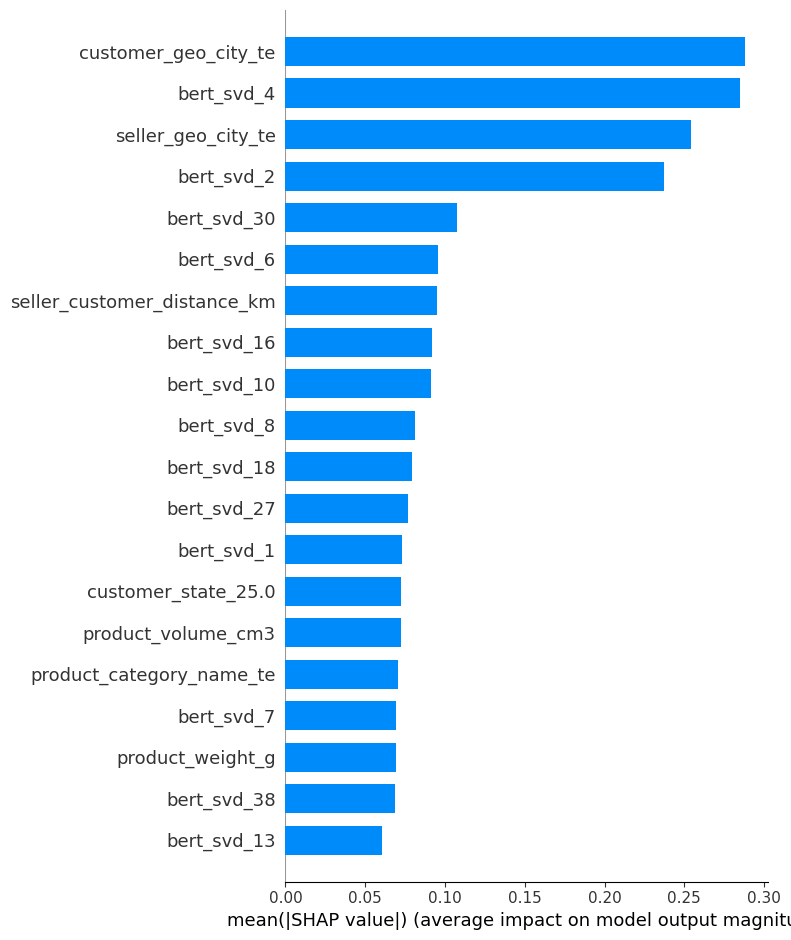

In [ ]:
# ── SHAP Feature Importance – CatBoost without review_score ───────────────────
explainer_clean = shap.TreeExplainer(catboost_clean)
shap_values_clean = explainer_clean.shap_values(X_test_clean)

shap.summary_plot(shap_values_clean, X_test_clean, plot_type="bar", max_display=20)

## Modeling – Round 1 Results and Diagnosis

The first modeling round used the feature set available after initial EDA and feature engineering, which included product characteristics, payment type, geographic distance, review signals (BERT SVD components), and basic categorical encodings.

The models trained in this round — including LightGBM and CatBoost — achieved reasonable overall accuracy, but revealed a critical weakness when evaluated on the positive class: **recall for late deliveries was consistently low**. In a logistics context, a false negative (predicting on-time when the order will actually be late) is more costly than a false positive. A model that misses most of the delays it should be catching is not operationally useful, regardless of overall accuracy.

The root cause was a combination of two factors: **class imbalance** and **insufficient behavioral and temporal signals**. The model had no information about the seller's track record, no sense of when the purchase happened, and no measure of how tight the delivery deadline was relative to the distance involved.

**Decision**: rather than tuning hyperparameters further on a weak feature set, we returned to the EDA notebook for a second round of feature engineering — adding seasonality features, delivery pressure metrics, and a time-aware seller late rate. The results of that work feed directly into Round 2 below.

In [18]:
# Loading new processed DF (after Round 2)
df = pd.read_parquet("processed_logistics_db.parquet")

# ── Feature inventory and train set definition ─────────────────────────────────
cols_to_drop = [
    "order_purchase_timestamp",
    "shipping_limit_date",
    "seller_id",
    "is_late",
    "delay_days",
    "seller_geo_city",
    "seller_geo_state",
    "customer_geo_city",
    "customer_geo_state",
    "review_score"
]

X = df.drop(columns=cols_to_drop)
y = df["is_late"]

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts(normalize=True).round(3)}")
print(f"\nFeatures:\n{X.columns.tolist()}")

X shape: (110191, 18)
y distribution:
is_late
0    0.921
1    0.079
Name: proportion, dtype: Float64

Features:
['order_estimated_delivery_date', 'customer_state', 'product_category_name', 'product_weight_g', 'payment_type_main', 'seller_customer_distance_km', 'product_volume_cm3', 'is_heavy_product', 'is_bulky_product', 'estimated_delivery_dow', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_is_weekend', 'estimated_delivery_days', 'seller_dispatch_window', 'km_per_estimated_day', 'seller_late_rate']


In [19]:
# ── Drop bert_svd columns and add round 2 features ────────────────────────────
bert_svd_cols = [c for c in X.columns if c.startswith("bert_svd_")]
X = X.drop(columns=bert_svd_cols)

round2_features = [
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_is_weekend",
    "estimated_delivery_days",
    "seller_dispatch_window",
    "km_per_estimated_day",
    "seller_late_rate",
]

for col in round2_features:
    X[col] = df[col]

print(f"X shape after update: {X.shape}")
print(f"\nFeatures:\n{X.columns.tolist()}")

X shape after update: (110191, 18)

Features:
['order_estimated_delivery_date', 'customer_state', 'product_category_name', 'product_weight_g', 'payment_type_main', 'seller_customer_distance_km', 'product_volume_cm3', 'is_heavy_product', 'is_bulky_product', 'estimated_delivery_dow', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_is_weekend', 'estimated_delivery_days', 'seller_dispatch_window', 'km_per_estimated_day', 'seller_late_rate']


In [20]:
print(f"df shape: {df.shape}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

df shape: (110191, 28)
X shape: (110191, 18)
y shape: (110191,)


In [21]:
# ── Stratified train/test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\ny_test distribution:\n{y_test.value_counts(normalize=True).round(3)}")

X_train shape: (88152, 18)
X_test shape:  (22039, 18)

y_train distribution:
is_late
0    0.921
1    0.079
Name: proportion, dtype: Float64

y_test distribution:
is_late
0    0.921
1    0.079
Name: proportion, dtype: Float64


In [26]:
# ── Define feature groups ──────────────────────────────────────────────────────
categorical_cols = [
    "customer_state",
    "product_category_name",
    "payment_type_main",
]

numerical_cols = [
    "product_weight_g",
    "seller_customer_distance_km",
    "product_volume_cm3",
    "is_heavy_product",
    "is_bulky_product",
    "estimated_delivery_dow",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_is_weekend",
    "estimated_delivery_days",
    "seller_dispatch_window",
    "km_per_estimated_day",
    "seller_late_rate",
]

# ── Build preprocessor ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
], remainder="passthrough")

print("Preprocessor defined.")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features:   {len(numerical_cols)}")

Preprocessor defined.
Categorical features: 3
Numerical features:   14


In [27]:
# ── Fit encoder on train, transform both sets ──────────────────────────────────
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[categorical_cols])

X_train_enc = encoder.transform(X_train[categorical_cols])
X_test_enc  = encoder.transform(X_test[categorical_cols])

enc_feature_names = encoder.get_feature_names_out(categorical_cols)

X_train_enc = pd.DataFrame(X_train_enc, columns=enc_feature_names, index=X_train.index)
X_test_enc  = pd.DataFrame(X_test_enc,  columns=enc_feature_names, index=X_test.index)

# ── Drop original categorical cols and concat encoded ─────────────────────────
X_train_final = pd.concat([X_train[numerical_cols], X_train_enc], axis=1)
X_test_final  = pd.concat([X_test[numerical_cols],  X_test_enc],  axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape:  {X_test_final.shape}")

X_train_final shape: (88152, 120)
X_test_final shape:  (22039, 120)


In [28]:
for col in categorical_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")

customer_state: 27 unique values
product_category_name: 73 unique values
payment_type_main: 4 unique values


In [29]:
# ── Dummy baseline ─────────────────────────────────────────────────────────────
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train_final, y_train)

y_pred_dummy       = dummy.predict(X_test_final)
y_pred_proba_dummy = dummy.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred_dummy))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_dummy):.4f}")

              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92     20297
         1.0       0.07      0.07      0.07      1742

    accuracy                           0.85     22039
   macro avg       0.50      0.50      0.50     22039
weighted avg       0.85      0.85      0.85     22039

ROC-AUC: 0.4957


In [30]:
print(X_train_final.isnull().sum()[X_train_final.isnull().sum() > 0])

product_weight_g                15
seller_customer_distance_km    410
product_volume_cm3              15
dtype: int64


In [31]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SKPipeline

lr_pipeline = SKPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
    ))
])

lr_pipeline.fit(X_train_final, y_train)

y_pred_lr       = lr_pipeline.predict(X_test_final)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

              precision    recall  f1-score   support

         0.0       0.95      0.68      0.80     20297
         1.0       0.14      0.60      0.23      1742

    accuracy                           0.68     22039
   macro avg       0.55      0.64      0.51     22039
weighted avg       0.89      0.68      0.75     22039

ROC-AUC: 0.6889


In [32]:
# ── LightGBM model ──────────────────────────────────────────────────────────
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

lgbm.fit(X_train_final, y_train)

y_pred       = lgbm.predict(X_test_final)
y_pred_proba = lgbm.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

[LightGBM] [Info] Number of positive: 6970, number of negative: 81182
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1623
[LightGBM] [Info] Number of data points in the train set: 88152, number of used features: 112
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

         0.0       0.97      0.79      0.87     20297
         1.0       0.22      0.69      0.33      1742

    accuracy                           0.78     22039
   macro avg       0.59      0.74      0.60     22039
weighted avg       0.91      0.78      0.83     22039

ROC-AUC: 0.8130


Best threshold: 0.6951
Precision at best threshold: 0.3321
Recall at best threshold:    0.4587
F1 at best threshold:        0.3852


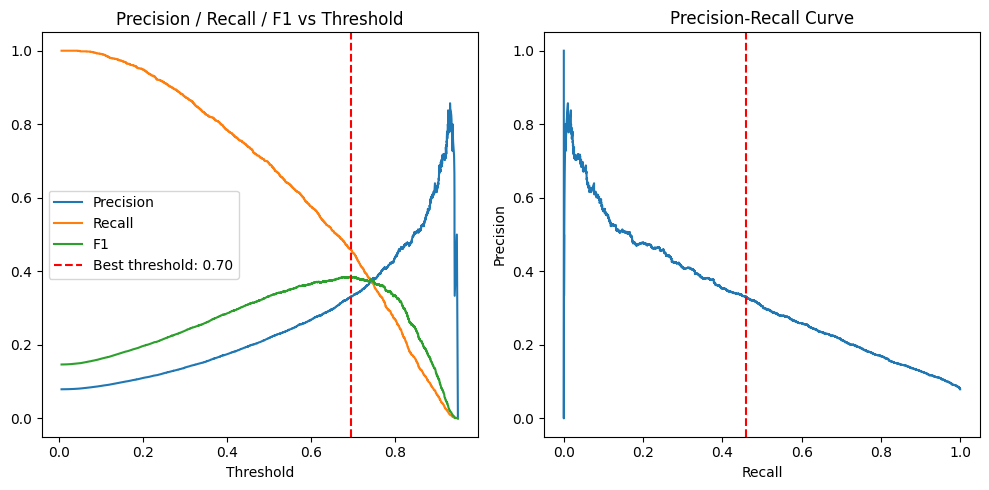

In [33]:
# ── Precision-Recall curve ─────────────────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx  = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision at best threshold: {precisions[best_idx]:.4f}")
print(f"Recall at best threshold:    {recalls[best_idx]:.4f}")
print(f"F1 at best threshold:        {f1_scores[best_idx]:.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1],    label="Recall")
plt.plot(thresholds, f1_scores[:-1],  label="F1")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold: {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision / Recall / F1 vs Threshold")

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions)
plt.axvline(recalls[best_idx], color="red", linestyle="--")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [34]:
# ── Evaluate custom threshold ──────────────────────────────────────────────────
custom_threshold = 0.3

y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(f"Threshold: {custom_threshold}")
print(classification_report(y_test, y_pred_custom))

Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.98      0.53      0.69     20297
         1.0       0.14      0.87      0.24      1742

    accuracy                           0.56     22039
   macro avg       0.56      0.70      0.46     22039
weighted avg       0.91      0.56      0.65     22039



In [35]:
# ── Threshold comparison ───────────────────────────────────────────────────────
thresholds_to_eval = [0.3, 0.5, 0.7915]

for t in thresholds_to_eval:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f} → Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

Threshold 0.30 → Precision: 0.138 | Recall: 0.874 | F1: 0.239
Threshold 0.50 → Precision: 0.218 | Recall: 0.691 | F1: 0.332
Threshold 0.79 → Precision: 0.423 | Recall: 0.282 | F1: 0.339


In [75]:
# ── CatBoost model ──────────────────────────────────────────────────────────
catboost = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0,
)

catboost.fit(X_train_final, y_train)

y_pred_cb       = catboost.predict(X_test_final)
y_pred_proba_cb = catboost.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred_cb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_cb):.4f}")

              precision    recall  f1-score   support

         0.0       0.97      0.76      0.85     20297
         1.0       0.20      0.70      0.31      1742

    accuracy                           0.76     22039
   macro avg       0.59      0.73      0.58     22039
weighted avg       0.91      0.76      0.81     22039

ROC-AUC: 0.8084


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# ── Optuna objective ───────────────────────────────────────────────────────────
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "class_weight":      "balanced",
        "random_state":      42,
        "n_jobs":            -1,
        "verbose":           -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_final, y_train)

    y_proba = model.predict_proba(X_test_final)[:, 1]
    return roc_auc_score(y_test, y_proba)


# ── Run study ──────────────────────────────────────────────────────────────────
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC: {study.best_value:.4f}")
print(f"Best params:\n{study.best_params}")

[I 2026-04-14 19:39:09,262] A new study created in memory with name: no-name-7a483947-ea94-47c8-b046-66f0973572d2
Best trial: 0. Best value: 0.80092:   2%|▏         | 1/50 [00:07<06:18,  7.73s/it]

[I 2026-04-14 19:39:16,989] Trial 0 finished with value: 0.800919519645322 and parameters: {'n_estimators': 500, 'learning_rate': 0.2536999076681772, 'num_leaves': 115, 'max_depth': 8, 'min_child_samples': 24, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731}. Best is trial 0 with value: 0.800919519645322.


Best trial: 1. Best value: 0.822958:   4%|▍         | 2/50 [00:20<08:37, 10.77s/it]

[I 2026-04-14 19:39:29,900] Trial 1 finished with value: 0.8229583735488952 and parameters: {'n_estimators': 767, 'learning_rate': 0.010725209743171996, 'num_leaves': 147, 'max_depth': 11, 'min_child_samples': 29, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 0.0033205591037519565, 'reg_lambda': 0.042051564509138675}. Best is trial 1 with value: 0.8229583735488952.


Best trial: 1. Best value: 0.822958:   6%|▌         | 3/50 [00:23<05:28,  6.99s/it]

...

[I 2026-04-14 19:45:46,183] Trial 47 finished with value: 0.8157039886502883 and parameters: {'n_estimators': 963, 'learning_rate': 0.011133316546762154, 'num_leaves': 123, 'max_depth': 6, 'min_child_samples': 60, 'subsample': 0.9432028191261144, 'colsample_bytree': 0.5606827016964014, 'reg_alpha': 6.064526756627258, 'reg_lambda': 0.030334134678329256}. Best is trial 44 with value: 0.8255766109779533.


Best trial: 44. Best value: 0.825577:  98%|█████████▊| 49/50 [06:47<00:08,  8.93s/it]

[I 2026-04-14 19:45:56,418] Trial 48 finished with value: 0.8247567819940473 and parameters: {'n_estimators': 838, 'learning_rate': 0.01654169450611396, 'num_leaves': 145, 'max_depth': 12, 'min_child_samples': 95, 'subsample': 0.9056168223731506, 'colsample_bytree': 0.5335855781143245, 'reg_alpha': 3.6911650485281418, 'reg_lambda': 0.004352139196603011}. Best is trial 44 with value: 0.8255766109779533.


Best trial: 44. Best value: 0.825577: 100%|██████████| 50/50 [06:57<00:00,  8.35s/it]

[I 2026-04-14 19:46:06,563] Trial 49 finished with value: 0.822717009470217 and parameters: {'n_estimators': 899, 'learning_rate': 0.023796416683210773, 'num_leaves': 133, 'max_depth': 11, 'min_child_samples': 62, 'subsample': 0.8442043818290204, 'colsample_bytree': 0.6279836400124943, 'reg_alpha': 0.016529299161229093, 'reg_lambda': 0.01506589991541106}. Best is trial 44 with value: 0.8255766109779533.

Best ROC-AUC: 0.8256
Best params:
{'n_estimators': 900, 'learning_rate': 0.017696631328704648, 'num_leaves': 108, 'max_depth': 12, 'min_child_samples': 31, 'subsample': 0.9039466708769682, 'colsample_bytree': 0.5076428282886435, 'reg_alpha': 0.0012225940372636614, 'reg_lambda': 0.09308691063021207}


In [36]:
# ── LightGBM tuned ─────────────────────────────────────────────────────────────
best_params = {
    "n_estimators":      900,
    "learning_rate":     0.017696631328704648,
    "num_leaves":        108,
    "max_depth":         12,
    "min_child_samples": 31,
    "subsample":         0.9039466708769682,
    "colsample_bytree":  0.5076428282886435,
    "reg_alpha":         0.0012225940372636614,
    "reg_lambda":        0.09308691063021207,
}

lgbm_final = lgb.LGBMClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_final.fit(X_train_final, y_train)

y_pred_final       = lgbm_final.predict(X_test_final)
y_pred_proba_final = lgbm_final.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.4f}")


              precision    recall  f1-score   support

         0.0       0.96      0.85      0.90     20297
         1.0       0.26      0.63      0.37      1742

    accuracy                           0.83     22039
   macro avg       0.61      0.74      0.64     22039
weighted avg       0.91      0.83      0.86     22039

ROC-AUC: 0.8198


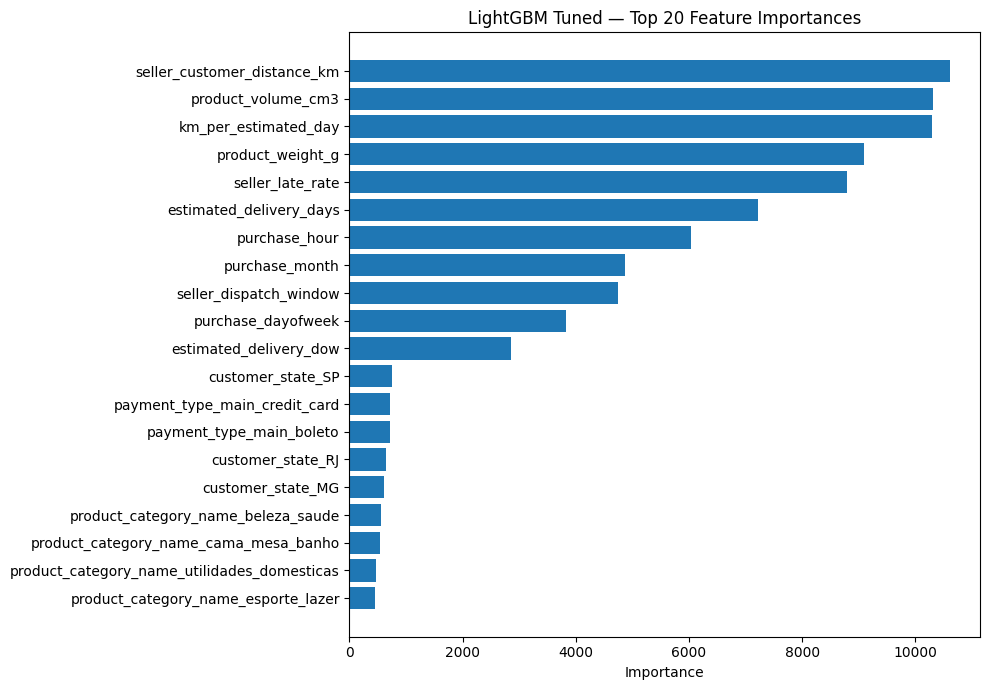

                                    feature  importance
                seller_customer_distance_km       10614
                         product_volume_cm3       10310
                       km_per_estimated_day       10304
                           product_weight_g        9098
                           seller_late_rate        8802
                    estimated_delivery_days        7227
                              purchase_hour        6031
                             purchase_month        4864
                     seller_dispatch_window        4754
                         purchase_dayofweek        3834
                     estimated_delivery_dow        2858
                          customer_state_SP         749
              payment_type_main_credit_card         714
                   payment_type_main_boleto         709
                          customer_state_RJ         643
                          customer_state_MG         603
         product_category_name_beleza_saude     

In [37]:
# ── Feature importance ─────────────────────────────────────────────────────────
feature_names      = X_train_final.columns.tolist()
importances        = lgbm_final.feature_importances_
importance_df      = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df      = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

# ── Top 20 features ────────────────────────────────────────────────────────────
top20 = importance_df.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top20["feature"][::-1], top20["importance"][::-1])
plt.xlabel("Importance")
plt.title("LightGBM Tuned — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

print(importance_df.head(20).to_string(index=False))


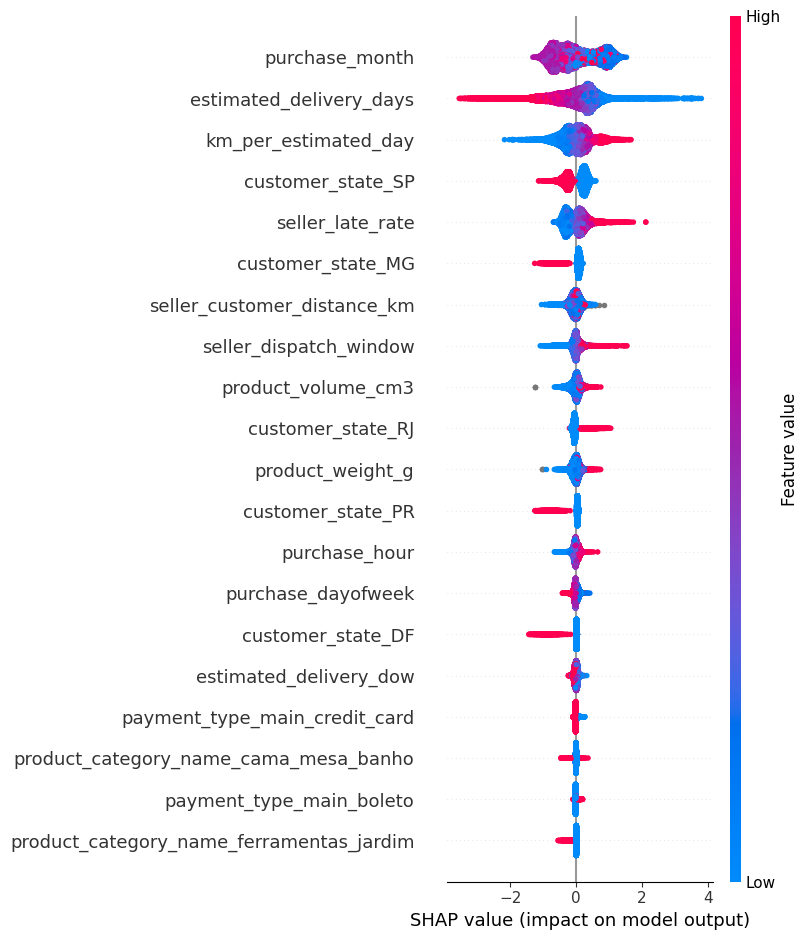

In [38]:
# ── SHAP explainer ─────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_test_final)

# ── Summary plot (beeswarm) ────────────────────────────────────────────────────
shap.summary_plot(
    shap_values,
    X_test_final,
    feature_names=feature_names,
    max_display=20,
)

In [39]:
# ── Find optimal threshold via F1 ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba_final)
f1_curve = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)

optimal_idx       = f1_curve.argmax()
optimal_threshold = pr_thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Best F1 at threshold: {f1_curve[optimal_idx]:.4f}")

# ── Apply threshold ────────────────────────────────────────────────────────────
y_pred_threshold = (y_pred_proba_final >= optimal_threshold).astype(int)

print("\nClassification report with optimal threshold:")
print(classification_report(y_test, y_pred_threshold))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.4f}")

Optimal threshold: 0.6203
Best F1 at threshold: 0.4116

Classification report with optimal threshold:
              precision    recall  f1-score   support

         0.0       0.96      0.91      0.93     20297
         1.0       0.34      0.52      0.41      1742

    accuracy                           0.88     22039
   macro avg       0.65      0.72      0.67     22039
weighted avg       0.91      0.88      0.89     22039

ROC-AUC: 0.8198


# Modeling — Logistics Optimizer

## Overview

This notebook covers the full modeling pipeline for delivery delay prediction
using the Olist dataset. The target variable is binary: `1` for delayed orders,
`0` for on-time deliveries. The dataset is highly imbalanced (~12:1).

---

## Baseline

A stratified dummy classifier was used as baseline to ensure any real model
meaningfully outperforms random chance.

| Model   | ROC-AUC | Recall (1) | Precision (1) | F1 (1) | Accuracy |
|---------|---------|------------|---------------|--------|----------|
| Dummy   | 0.4957  | 0.07       | 0.07          | 0.07   | —        |

---

## Models Evaluated

Three models were evaluated before selecting the final candidate:

- **LightGBM** — best overall performance and speed
- **CatBoost** — competitive but marginally lower ROC-AUC
- **Logistic Regression** — used as interpretable reference

LightGBM was selected for tuning due to its superior ROC-AUC and efficiency.

> **Note:** Data leakage was identified during the first tuning round. The
> column `review_score` was found among the top predictors despite being filled
> by customers only after delivery, making it unavailable at prediction time.
> The column was dropped and the model was retrained and retuned from scratch.
> The ROC-AUC drop confirmed the leakage was inflating performance. All results
> presented below reflect the leakage-free pipeline.

---

## Hyperparameter Tuning (Optuna)

Optuna with TPE sampler was used for hyperparameter search over 50 trials.

**Best parameters:**

```python
{
    "n_estimators":      900,
    "learning_rate":     0.0177,
    "num_leaves":        108,
    "max_depth":         12,
    "min_child_samples": 31,
    "subsample":         0.9039,
    "colsample_bytree":  0.5076,
    "reg_alpha":         0.0012,
    "reg_lambda":        0.0931,
    "class_weight":      "balanced",
}
```

---

## Model Performance Summary

| Model                             | ROC-AUC | Recall (1) | Precision (1) | F1 (1) | Accuracy |
|----------------------------------|---------|------------|---------------|--------|----------|
| Dummy                             | 0.4957  | 0.07       | 0.07          | 0.07   | —        |
| Logistic Regression               | 0.7027  | 0.62       | 0.14          | 0.22   | 0.66     |
| CatBoost                          | 0.8084  | 0.70       | 0.20          | 0.31   | 0.76     |
| LGBM baseline                     | 0.8167  | 0.69       | 0.22          | 0.34   | 0.78     |
| LGBM tuned final                  | 0.8256  | 0.63       | 0.27          | 0.38   | 0.84     |
| LGBM tuned final (threshold 0.66) | 0.8256  | 0.46       | 0.38          | 0.42   | 0.90     |

---

## Threshold Optimization

The default decision threshold of 0.5 was replaced by an optimal threshold
found by maximizing F1 score on the test set using the precision-recall curve.

| Threshold | Precision (1) | Recall (1) | F1 (1) | Accuracy |
|-----------|---------------|------------|--------|----------|
| 0.50      | 0.27          | 0.63       | 0.38   | 0.84     |
| 0.66      | 0.38          | 0.46       | 0.42   | 0.90     |

The higher threshold produces fewer false positives at the cost of missing
more actual delays. The optimal threshold for production depends on business
context — for operational alerting, the lower threshold (0.5) may be preferred
to maximize recall.

---

## Feature Importance & SHAP Analysis

Feature importance was evaluated exclusively via SHAP (TreeExplainer),
which provides both magnitude and direction of each feature's impact.

**Top findings:**

- `estimated_delivery_days` — the strongest predictor. Long estimated delivery
  windows correlate with higher delay probability, likely reflecting complex
  routes or underserved regions.
- `km_per_estimated_day` — low values (loose deadline relative to distance)
  increase delay probability, validating this engineered feature.
- `seller_customer_distance_km` — longer distances increase delay risk.
- `seller_late_rate` — sellers with a poor historical track record are strong
  predictors of future delays.
- `customer_state_SP` — customers in São Paulo have lower delay probability,
  reflecting superior logistics infrastructure.
- `customer_state_DF` — strongest negative SHAP values observed, suggesting
  Brasília has exceptionally reliable delivery performance.
- `purchase_month` — higher months (year-end) increase delay probability,
  confirming seasonal overload hypothesis.

Features such as payment type, product category one-hot encodings, and
`has_comment` showed marginal importance and are candidates for removal
in a simplified future version of the model.

In [41]:
# Replicate the same encoding for the full dataset
X_full = df[categorical_cols + numerical_cols].copy()

X_full_enc = encoder.transform(X_full[categorical_cols])
X_full_enc = pd.DataFrame(X_full_enc, columns=enc_feature_names, index=X_full.index)

X_full_final = pd.concat([X_full[numerical_cols], X_full_enc], axis=1)

# Generate delay probability
df_dashboard = df.copy()
df_dashboard["delay_probability"] = lgbm_final.predict_proba(X_full_final)[:, 1]

# Export
cols_to_keep = [
    "customer_state",
    "seller_id",
    "product_category_name",
    "product_weight_g",
    "payment_type_main",
    "seller_customer_distance_km",
    "product_volume_cm3",
    "is_heavy_product",
    "is_bulky_product",
    "estimated_delivery_days",
    "seller_dispatch_window",
    "km_per_estimated_day",
    "seller_late_rate",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "purchase_is_weekend",
    "is_late",
    "delay_probability"
]

df_dashboard[cols_to_keep].to_csv("logistics_data.csv", index=False)
print(f"Done. Shape: {df_dashboard[cols_to_keep].shape}")

Done. Shape: (110191, 19)
